In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


In [22]:
df = pd.read_csv('churn.csv')

In [23]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [25]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [26]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [27]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [28]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [29]:
results = df['Exited'].value_counts()

In [30]:
results

Exited
0    7963
1    2037
Name: count, dtype: int64

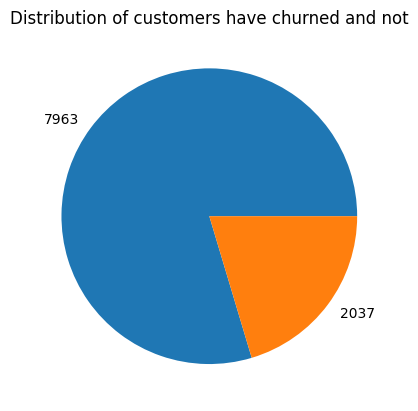

In [31]:
plt.pie(results, labels=results)
plt.title('Distribution of customers have churned and not')
plt.show()

In [32]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [33]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

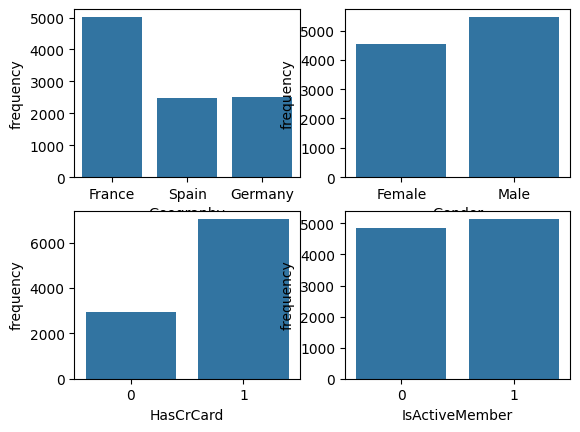

In [34]:
categorical_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

for i, column in enumerate(categorical_features):
    plt.subplot(2,2, i+1)
    sns.countplot(x=df[column])
    #plt.title(column)
    plt.xlabel(column)
    plt.ylabel('frequency')

plt.show()

In [35]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

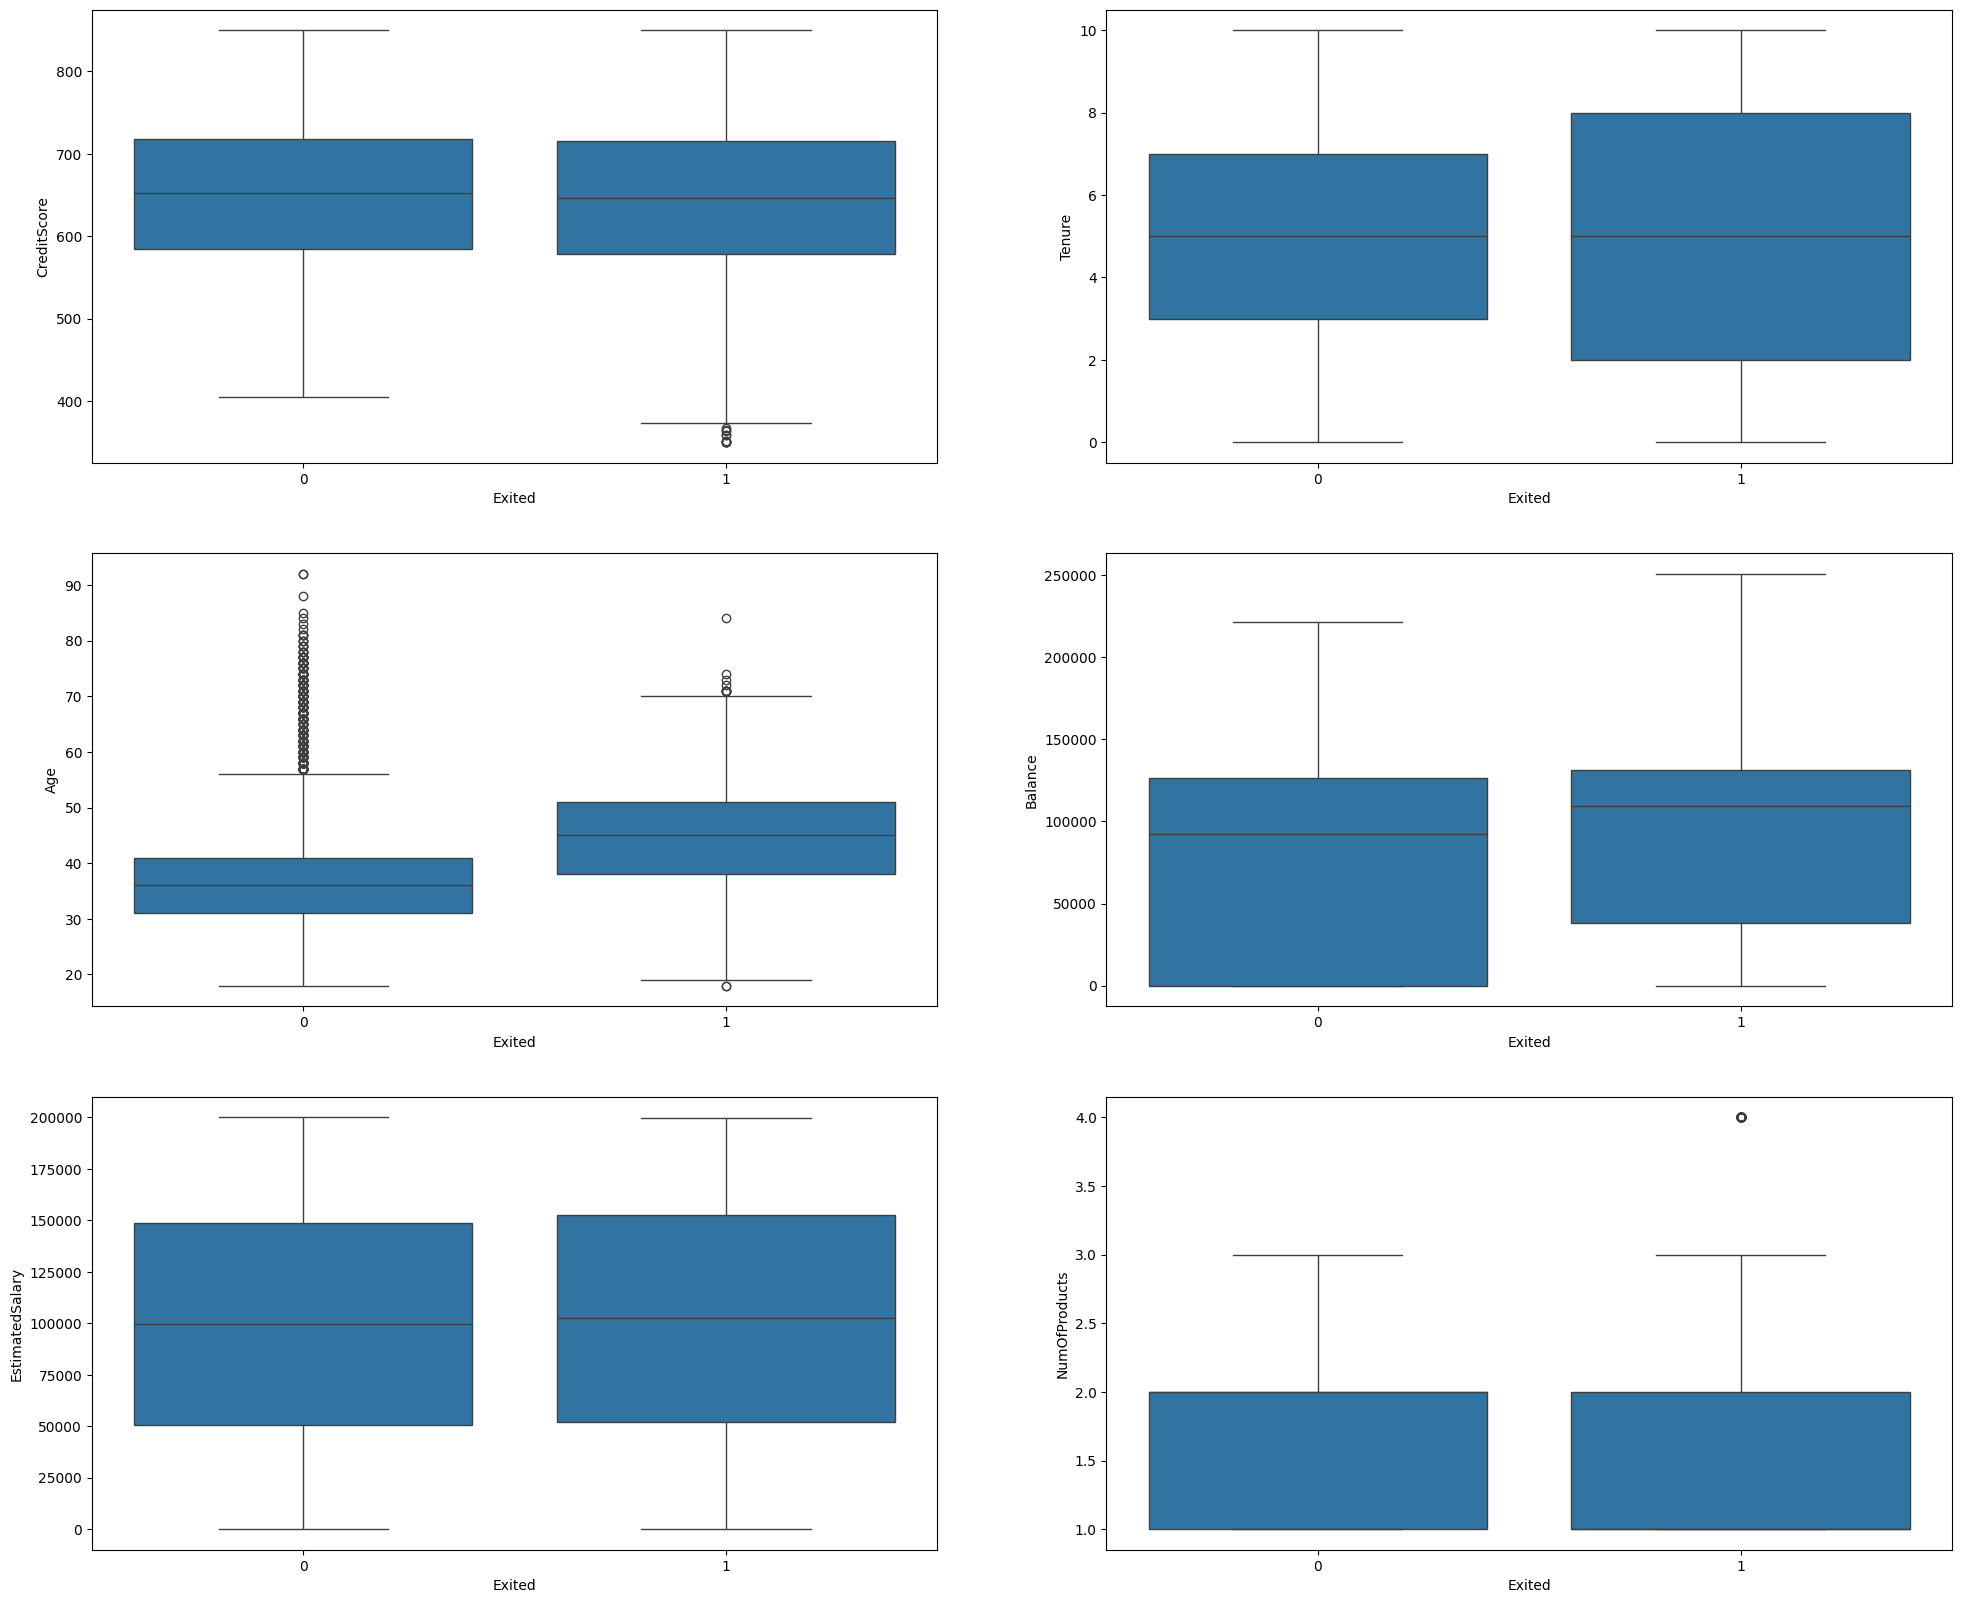

In [36]:
fig, ax = plt.subplots(3,2, figsize=(24,20))

# CreditScore
sns.boxplot(data=df, x='Exited', y='CreditScore', ax=ax[0,0])
# Tenure
sns.boxplot(data=df, x='Exited', y='Tenure', ax=ax[0,1])
# Age
sns.boxplot(data=df, x='Exited', y='Age', ax=ax[1,0])
# Balance 
sns.boxplot(data=df, x='Exited', y='Balance', ax=ax[1,1])
# ExtimatedSalary
sns.boxplot(data=df, x='Exited', y='EstimatedSalary', ax=ax[2,0])
# No. of products
sns.boxplot(data=df, x='Exited', y='NumOfProducts', ax=ax[2,1])

plt.show()

##### 4. 

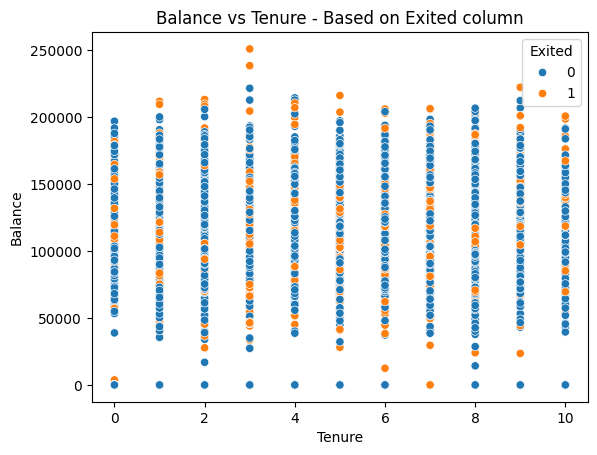

In [37]:
sns.scatterplot(data=df, x='Tenure', y='Balance', hue='Exited')
plt.title('Balance vs Tenure - Based on Exited column')
plt.show()

In [38]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [39]:
df['CreditUtilization'] = df['Balance']/df['CreditScore']
# Interaction Score
df['InteractionScore'] = df['NumOfProducts'] + df['HasCrCard'] + df['IsActiveMember']
# Balance to Salary Ratio
df['BalanceToSalary'] = df['Balance']/df['EstimatedSalary']

In [40]:
df_new = df.drop(['Surname', 'RowNumber', 'CustomerId', 'Geography', 'Gender'], axis=1)

In [41]:
df_new

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000
1,608,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677
2,502,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000
4,850,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000
9996,516,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108
9997,709,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000
9998,772,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230


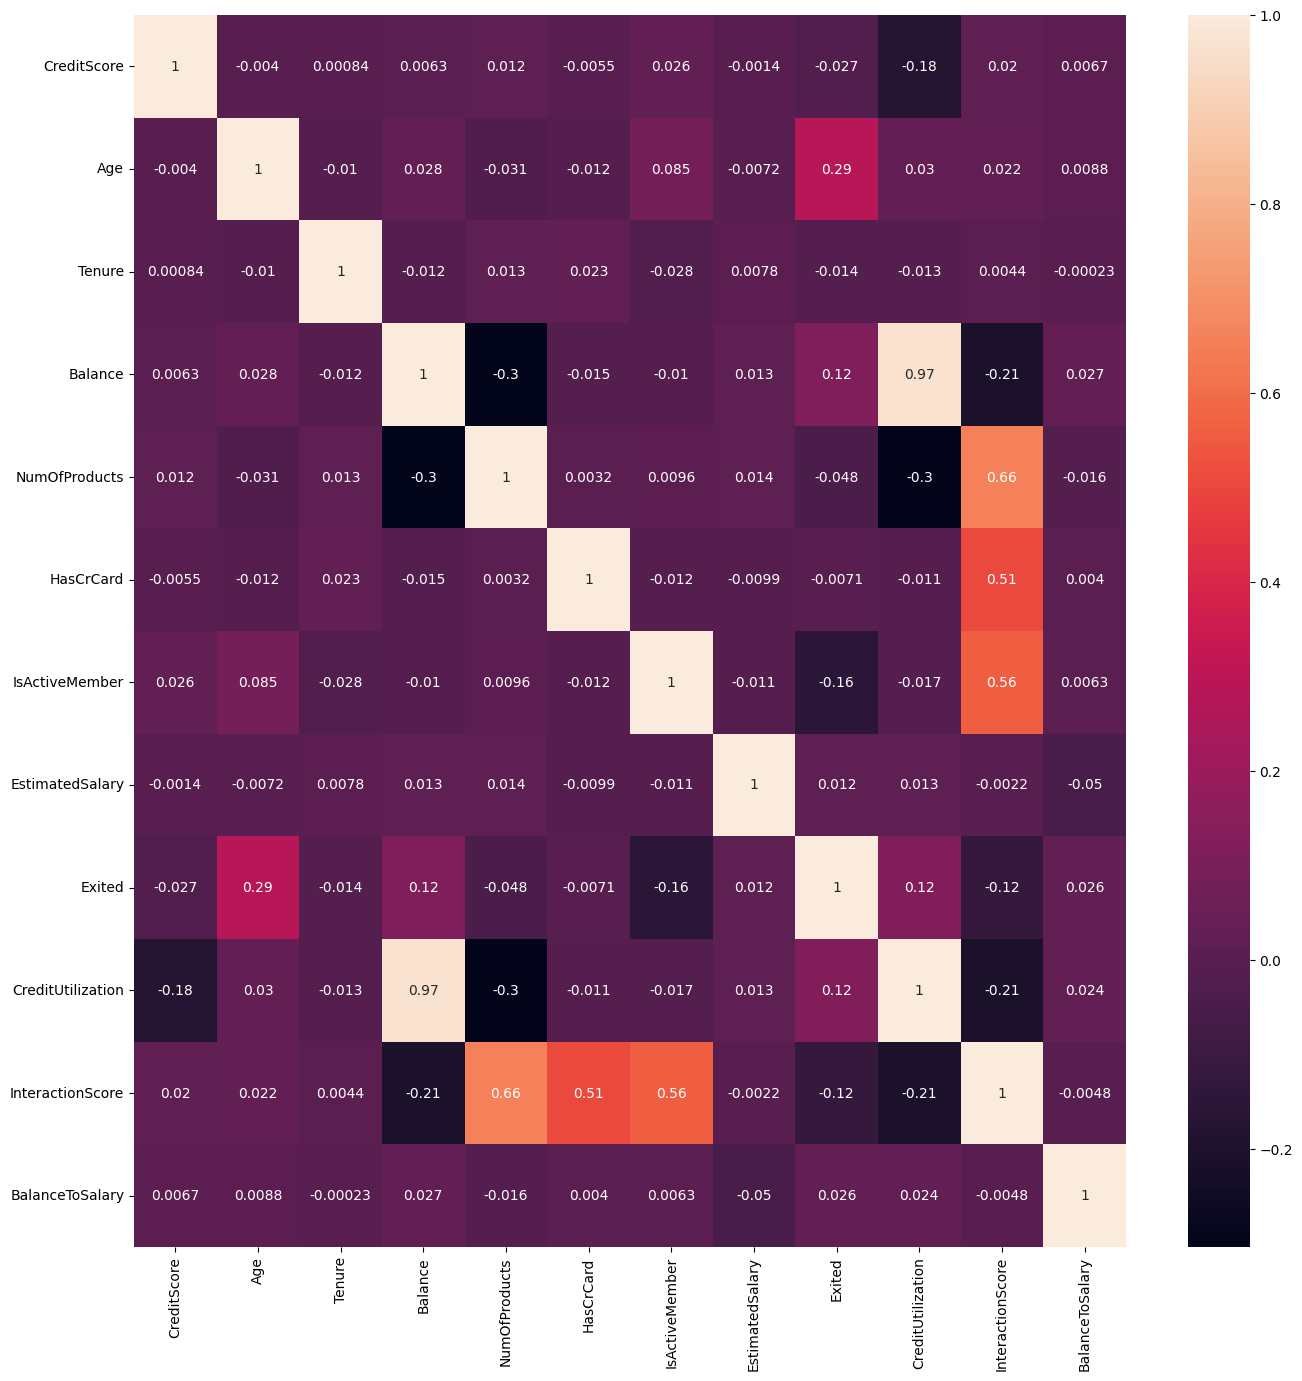

In [42]:
plt.figure(figsize=(16,16))
sns.heatmap(df_new.corr(), annot=True)

plt.show()

In [43]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230


In [44]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [45]:
label_encoder = LabelEncoder()

df['Gender'] = label_encoder.fit_transform(df['Gender'])  # Male =1 , Female=0

In [46]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary
0,619,France,0,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375
3,699,France,0,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,1,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000
9996,516,France,1,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108
9997,709,France,0,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000
9998,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230


In [47]:
df['Gender'].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

In [48]:
# Step 4: One-Hot Encode Geography
ohe = OneHotEncoder(sparse_output=False) 

geo_encoded = ohe.fit_transform(df[['Geography']])

In [49]:
geo_encoded

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]], shape=(10000, 3))

In [50]:
ohe.get_feature_names_out()

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [51]:
geo_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out())

In [52]:
df = df.drop('Geography', axis=1)

In [53]:
# Combine encoded Geography with the rest of the dataset
df = pd.concat([df, geo_df], axis=1)

In [54]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditUtilization,InteractionScore,BalanceToSalary,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.000000,3,0.000000,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,137.841875,2,0.744677,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,318.049402,4,1.401375,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.000000,2,0.000000,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,147.659788,3,1.587055,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,0.000000,3,0.000000,1.0,0.0,0.0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,111.181415,3,0.564108,1.0,0.0,0.0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,0.000000,2,0.000000,1.0,0.0,0.0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,97.247811,3,0.808230,0.0,1.0,0.0


In [55]:
df.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'CreditUtilization', 'InteractionScore', 'BalanceToSalary',
       'Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [56]:
X = df.drop(['Exited'], axis=1)
Y = df['Exited']

In [57]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
Logistic_regression = LogisticRegression(max_iter=10000,  class_weight='balanced')

In [60]:
X_train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,CreditUtilization,InteractionScore,BalanceToSalary,Geography_France,Geography_Germany,Geography_Spain
9069,619,0,32,4,175406.13,2,1,1,172792.43,283.370162,4,1.015126,0.0,0.0,1.0
2603,643,0,34,7,160426.07,1,0,1,188533.11,249.496221,2,0.850917,0.0,1.0,0.0
7738,561,1,33,6,0.00,2,0,0,173680.39,0.000000,2,0.000000,1.0,0.0,0.0
1579,618,1,41,8,37702.79,1,1,1,195775.48,61.007751,3,0.192582,0.0,1.0,0.0
5058,714,1,37,9,148466.93,2,0,1,151280.96,207.936877,3,0.981399,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,768,1,54,8,69712.74,1,1,1,69381.05,90.771797,3,1.004781,1.0,0.0,0.0
5191,682,0,58,1,0.00,1,1,1,706.50,0.000000,3,0.000000,1.0,0.0,0.0
5390,735,0,38,1,0.00,3,0,0,92220.12,0.000000,3,0.000000,1.0,0.0,0.0
860,667,1,43,8,190227.46,1,1,0,97508.04,285.198591,2,1.950890,1.0,0.0,0.0


In [61]:
Y_train

9069    1
2603    0
7738    0
1579    0
5058    0
       ..
5734    0
5191    0
5390    1
860     1
7270    0
Name: Exited, Length: 7000, dtype: int64

In [62]:
Logistic_regression.fit(X_train, Y_train)

c:\Users\Rafi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [63]:
y_pred = Logistic_regression.predict(X_test)

In [64]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.69      0.79      2416
           1       0.36      0.71      0.48       584

    accuracy                           0.70      3000
   macro avg       0.63      0.70      0.63      3000
weighted avg       0.80      0.70      0.73      3000



In [65]:
print(confusion_matrix(Y_test, y_pred))

[[1675  741]
 [ 171  413]]


<Axes: >

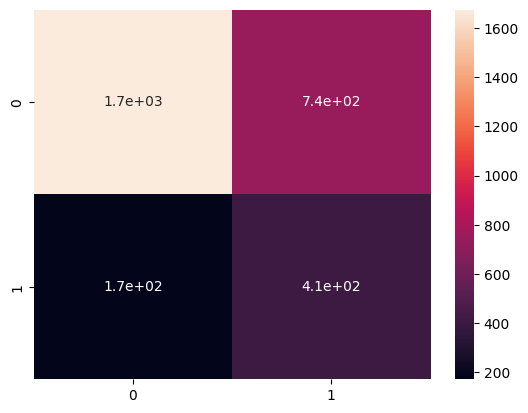

In [66]:
sns.heatmap(confusion_matrix(Y_test, y_pred), annot=True)

In [67]:
print(accuracy_score(Y_test, y_pred))

0.696


In [68]:
print(precision_score(Y_test, y_pred))

0.3578856152512998


In [69]:
print(recall_score(Y_test, y_pred))

0.7071917808219178


In [70]:
print(f1_score(Y_test, y_pred))

0.475258918296893


In [71]:
import joblib

In [72]:
joblib.dump(label_encoder, 'churn_label_encoder.pkl')
joblib.dump(ohe, 'churn_One_hot_encoder.pkl')
joblib.dump(scaler, 'churn_scalar.pkl')
joblib.dump(Logistic_regression, 'churn_logistic_regression_model.pkl')

['churn_logistic_regression_model.pkl']